---
format: 
    html:
        embed-resources: true
---


## EDA: Financial Statement Datasets and Ride Reliability Binary Dataset

In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [60]:
#load merged net position financial csv file dataset for eda
netposition_dataset = pd.read_csv("../../data/processed-data/Net_positions_reliability_binary.csv")
#convert csv file into a dataframe
netposition_df = pd.DataFrame(netposition_dataset)
#print first few rows of dataframe
print(netposition_df.head())
#print columns of dataframe
print(netposition_df.columns)


#load merged revenue financial csv file dataset for eda
revenue_dataset = pd.read_csv("../../data/processed-data/Revenue_reliability_binary.csv")
#convert csv file into a dataframe
revenue_df = pd.DataFrame(revenue_dataset)
#print first few rows of dataframe
print(revenue_df.head())
#print columns of dataframe
print(revenue_df.columns)


#load merged expenses financial csv file dataset for eda
expenses_dataset = pd.read_csv("../../data/processed-data/Expenses_reliability_binary.csv")
#convert csv file into a dataframe
expenses_df = pd.DataFrame(expenses_dataset)
#print first few rows of dataframe
print(expenses_df.head())
#print columns of dataframe
print(expenses_df.columns)


#load merged debts financial csv file dataset for eda
debts_dataset = pd.read_csv("../../data/processed-data/Debts_reliability_binary.csv")
#convert csv file into a dataframe
debts_df = pd.DataFrame(debts_dataset)
#print first few rows of dataframe
print(debts_df.head())
#print columns of dataframe
print(debts_df.columns)

   Unnamed: 0 Statements of Revenue, Expenses and Changes in Net Position  \
0           0                        Revenue from transportation            
1           1                           Total operating revenues            
2           2                            Transportation services            
3           3                           Other operating expenses            
4           4   Total operating expenses, excluding depreciation            

         Date  Net Position Amounts (USD)  ontime_trip_count  trip_count  \
0  2023-06-30                      376357               2925        3297   
1  2023-06-30                      452973               2925        3297   
2  2023-06-30                      822671               2925        3297   
3  2023-06-30                      968312               2925        3297   
4  2023-06-30                     1790983               2925        3297   

          Time  Pre and Post 2021  Pre and Post 2021 Binary  
0  04:00:00+00    

In [61]:
#drop unneeded columns
netposition_df_drop = netposition_df.drop(["Unnamed: 0"],axis=1)
revenue_df_drop = revenue_df.drop(["Unnamed: 0"],axis=1)
expenses_df_drop = expenses_df.drop(["Unnamed: 0"],axis=1)
debts_df_drop = debts_df.drop(["Unnamed: 0"],axis=1)

## Univariate Analysis:

In [62]:
#find outliers and other statistical information using describe() for the net position, revenue, expenses, and debts financial files
print(netposition_df_drop.describe())
print(revenue_df_drop.describe())
print(expenses_df_drop.describe())
print(debts_df_drop.describe())


       Net Position Amounts (USD)  ontime_trip_count   trip_count  \
count                6.500000e+01          65.000000    65.000000   
mean                 1.690963e+06        2419.400000  2664.200000   
std                  1.554446e+06         521.953596   635.363779   
min                  1.671140e+05        1825.000000  1894.000000   
25%                  7.771910e+05        1914.000000  1999.000000   
50%                  1.213708e+06        2329.000000  2727.000000   
75%                  2.013488e+06        2925.000000  3297.000000   
max                  7.603147e+06        3104.000000  3404.000000   

       Pre and Post 2021  Pre and Post 2021 Binary  
count       6.500000e+01                 65.000000  
mean        1.624994e+09                  0.200000  
std         4.497035e+07                  0.403113  
min         1.561853e+09                  0.000000  
25%         1.593475e+09                  0.000000  
50%         1.625011e+09                  0.000000  
75%    

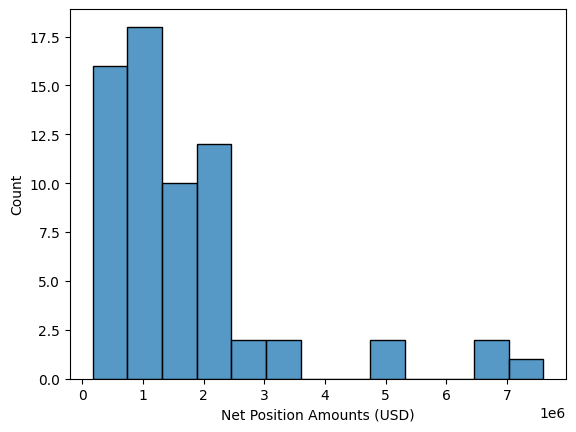

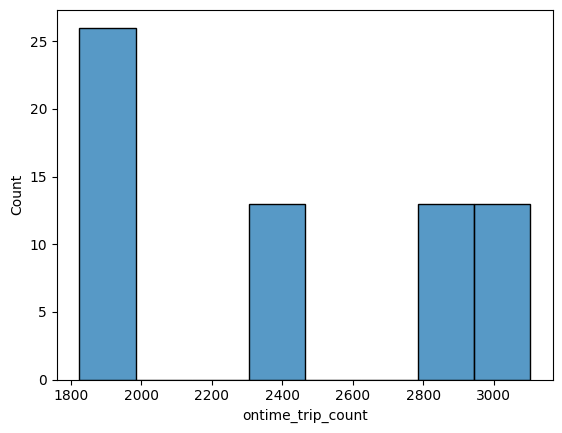

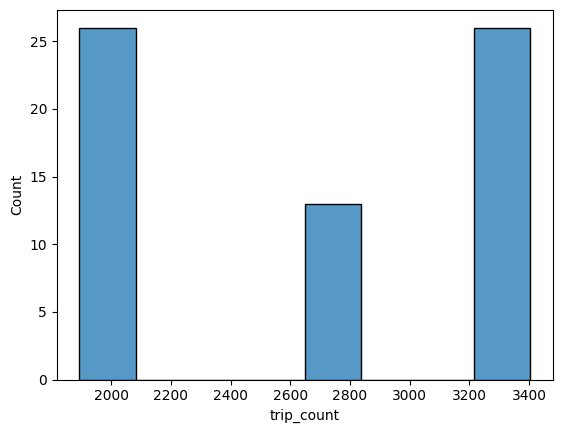

In [63]:
#create histogram plot from the net position dataframe
#numerical columns to make historgram for: 'Net Position Amounts (USD)', 'ontime_trip_count', 'trip_count'
sns.histplot(data = netposition_df_drop, x = "Net Position Amounts (USD)")
plt.show()

sns.histplot(data = netposition_df_drop, x = "ontime_trip_count")
plt.show()

sns.histplot(data = netposition_df_drop, x = "trip_count")
plt.show()

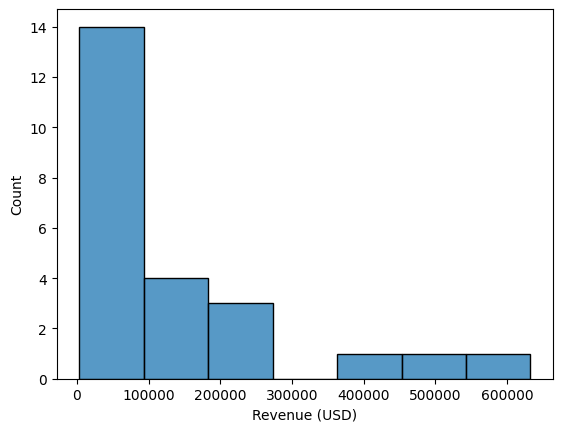

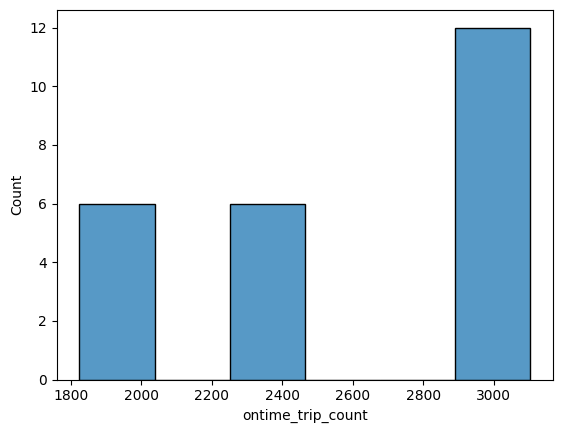

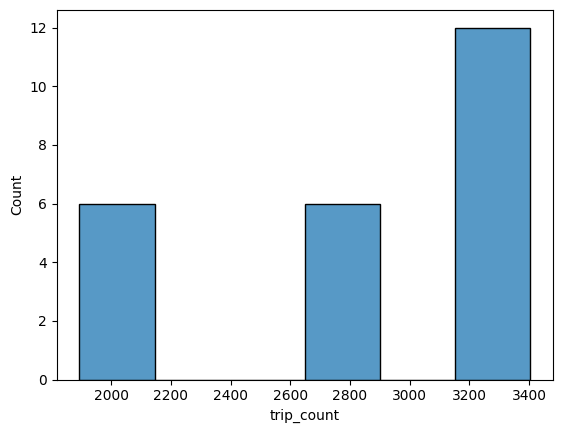

In [64]:
#create historgrams from the revenue dataframe
#numerical columns to use 'Revenue (USD)','ontime_trip_count', 'trip_count'

sns.histplot(data = revenue_df_drop, x = "Revenue (USD)")
plt.show()

sns.histplot(data = revenue_df_drop, x = "ontime_trip_count")
plt.show()

sns.histplot(data = revenue_df_drop, x = "trip_count")
plt.show()

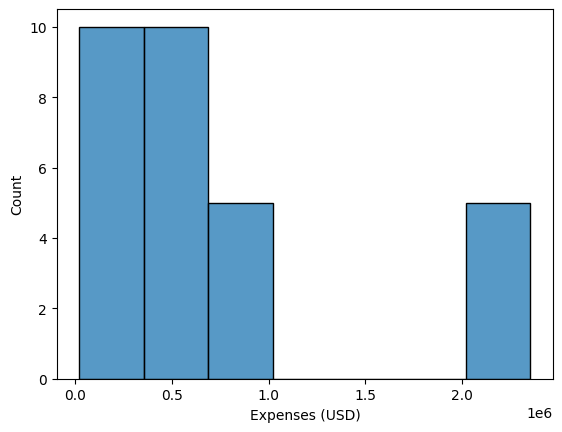

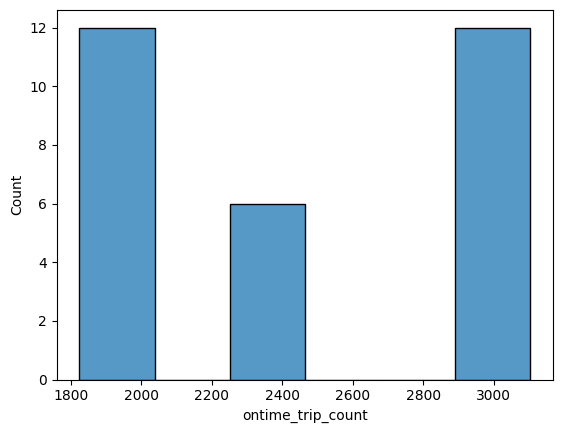

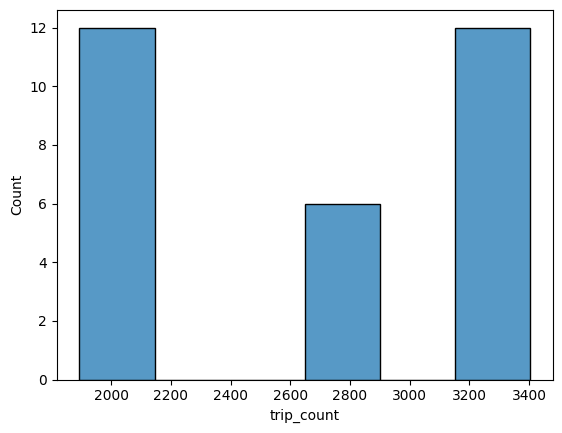

In [65]:
#create histogram plot from the expenses position dataframe
sns.histplot(data = expenses_df_drop, x = "Expenses (USD)")
plt.show()

sns.histplot(data = expenses_df_drop, x = "ontime_trip_count")
plt.show()

sns.histplot(data = expenses_df_drop, x = "trip_count")
plt.show()

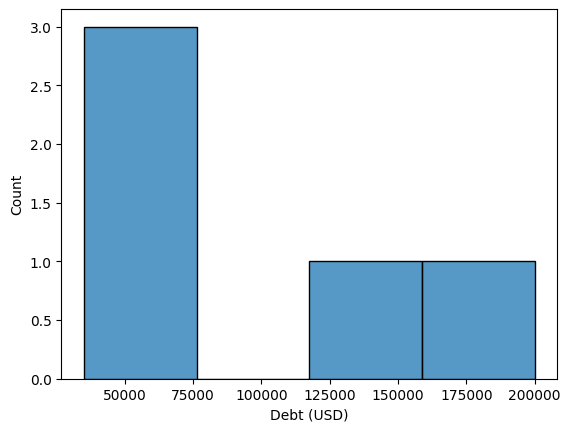

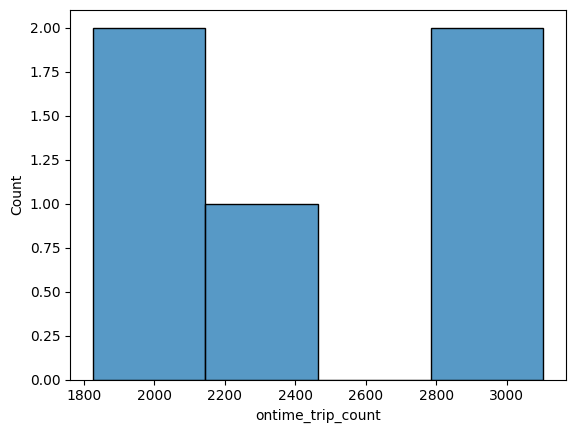

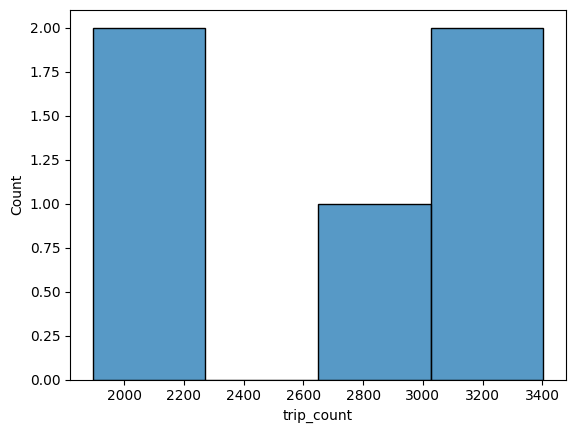

In [66]:
#create histogram plot from the debts position dataframe
sns.histplot(data = debts_df_drop, x = "Debt (USD)")
plt.show()

sns.histplot(data = debts_df_drop, x = "ontime_trip_count")
plt.show()

sns.histplot(data = debts_df_drop, x = "trip_count")
plt.show()

## Bivariate and Multivariate Analysis:

                            Net Position Amounts (USD)  ontime_trip_count  \
Net Position Amounts (USD)                    1.000000           0.193556   
ontime_trip_count                             0.193556           1.000000   
trip_count                                    0.196662           0.989030   
Pre and Post 2021 Binary                      0.131448           0.488103   

                            trip_count  Pre and Post 2021 Binary  
Net Position Amounts (USD)    0.196662                  0.131448  
ontime_trip_count             0.989030                  0.488103  
trip_count                    1.000000                  0.501858  
Pre and Post 2021 Binary      0.501858                  1.000000  


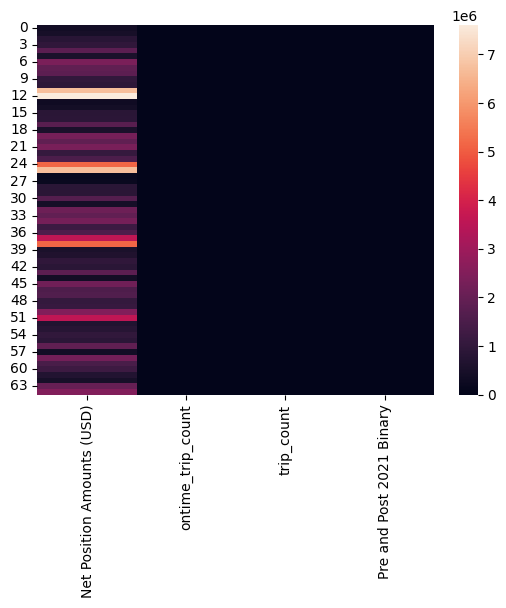

In [67]:
#create correlation matrix of the net position dataframe
#first subset dataframe to only include numerical columns
netposition_subset = netposition_df_drop[['Net Position Amounts (USD)', 'ontime_trip_count', 'trip_count', 'Pre and Post 2021 Binary']]
#create correlation matrix
netposition_corr_matrix = netposition_subset.corr()
print(netposition_corr_matrix)

#create heatmap of dataframe subset
sns.heatmap(netposition_subset)
plt.show() #show heatmap

                          Revenue (USD)  ontime_trip_count  trip_count  \
Revenue (USD)                  1.000000          -0.122285   -0.165140   
ontime_trip_count             -0.122285           1.000000    0.986635   
trip_count                    -0.165140           0.986635    1.000000   
Pre and Post 2021 Binary       0.042144           0.433195    0.449786   

                          Pre and Post 2021 Binary  
Revenue (USD)                             0.042144  
ontime_trip_count                         0.433195  
trip_count                                0.449786  
Pre and Post 2021 Binary                  1.000000  


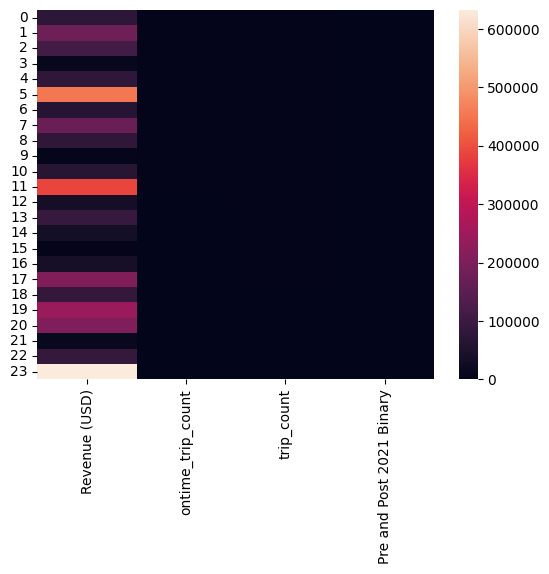

In [68]:
#create correlation matrix of the operating revenues dataframe
#first subset dataframe to only include numerical columns
rev_subset = revenue_df_drop[['Revenue (USD)', 'ontime_trip_count', 'trip_count', 'Pre and Post 2021 Binary']]
#create correlation matrix
rev_corr_matrix = rev_subset.corr()
print(rev_corr_matrix)

#create heatmap of dataframe subset
sns.heatmap(rev_subset)
plt.show() #show heatmap

                          Expenses (USD)  ontime_trip_count  trip_count  \
Expenses (USD)                  1.000000           0.020716    0.018052   
ontime_trip_count               0.020716           1.000000    0.989030   
trip_count                      0.018052           0.989030    1.000000   
Pre and Post 2021 Binary        0.026175           0.488103    0.501858   

                          Pre and Post 2021 Binary  
Expenses (USD)                            0.026175  
ontime_trip_count                         0.488103  
trip_count                                0.501858  
Pre and Post 2021 Binary                  1.000000  


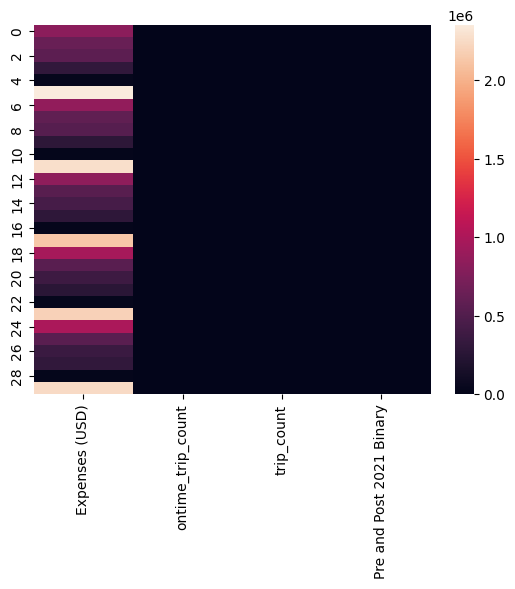

In [69]:
#create correlation matrix of the operating expenses dataframe
#first subset dataframe to only include numerical columns
exp_subset = expenses_df_drop[['Expenses (USD)', 'ontime_trip_count', 'trip_count', 'Pre and Post 2021 Binary']]
#create correlation matrix
exp_corr_matrix = exp_subset.corr()
print(exp_corr_matrix)

#create heatmap of dataframe subset
sns.heatmap(exp_subset)
plt.show() #show heatmap

                          Debt (USD)  ontime_trip_count  trip_count  \
Debt (USD)                  1.000000           0.159588    0.302755   
ontime_trip_count           0.159588           1.000000    0.989030   
trip_count                  0.302755           0.989030    1.000000   
Pre and Post 2021 Binary    0.273638           0.488103    0.501858   

                          Pre and Post 2021 Binary  
Debt (USD)                                0.273638  
ontime_trip_count                         0.488103  
trip_count                                0.501858  
Pre and Post 2021 Binary                  1.000000  


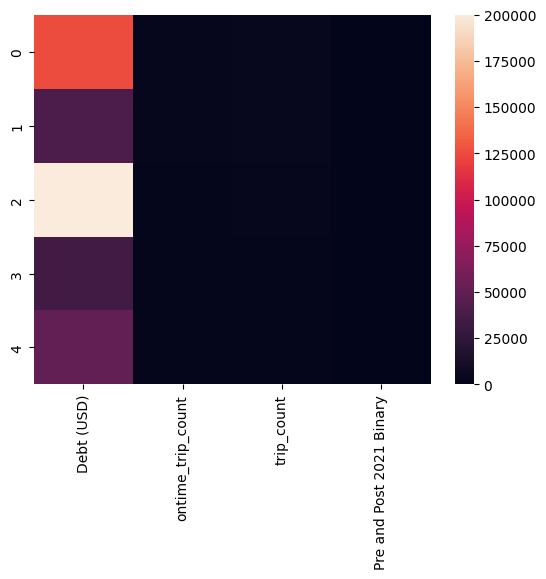

In [70]:
#create correlation matrix of the operating expenses dataframe
#first subset dataframe to only include numerical columns
debts_subset = debts_df_drop[['Debt (USD)', 'ontime_trip_count', 'trip_count', 'Pre and Post 2021 Binary']]
#create correlation matrix
debts_corr_matrix = debts_subset.corr()
print(debts_corr_matrix)

#create heatmap of dataframe subset
sns.heatmap(debts_subset)
plt.show() #show heatmap

In [71]:
#create crosstab of categorical variables
#crosstab variables Net position sources and Dates features
pd.crosstab(netposition_df_drop["Statements of Revenue, Expenses and Changes in Net Position"], netposition_df_drop["Date"])

Date,2019-06-30,2020-06-30,2021-06-30,2022-06-30,2023-06-30
"Statements of Revenue, Expenses and Changes in Net Position",,,,,
"Beginning of year, net position",1,1,1,1,1
Capital grants and contributions,1,1,1,1,1
Depreciation and amortization,1,1,1,1,1
"End of year, net position",1,1,1,1,1
Increase in net position,1,1,1,1,1
"Nonoperating revenue, net",1,1,1,1,1
Operating loss,1,1,1,1,1
Other operating expenses,1,1,1,1,1
Revenue from transportation,1,1,1,1,1


In [32]:
#crosstab variables Net position amounts and number of subway trips that were on-time
pd.crosstab(netposition_df_drop["Net Position Amounts (USD)"], netposition_df_drop["ontime_trip_count"])

ontime_trip_count,1825,1914,2329,2925,3104
Net Position Amounts (USD),,,,,
167114,0,0,1,0,0
206189,0,0,1,0,0
322292,0,0,0,0,1
364229,0,1,0,0,0
376357,0,0,0,1,0
...,...,...,...,...,...
2473146,1,1,0,0,0
3578852,1,0,1,0,0
5146804,0,0,1,0,1


In [34]:
#crosstab variables number of subway trips that were on-time before and after 2022-01-01
pd.crosstab(netposition_df_drop["ontime_trip_count"], netposition_df_drop["Pre and Post 2021 Binary"])

Pre and Post 2021 Binary,0,1
ontime_trip_count,,
1825,13,0
1914,13,0
2329,13,0
2925,0,13
3104,13,0


In [35]:
#crosstab variables number of subway trips before and after 2022-01-01
pd.crosstab(netposition_df_drop["trip_count"], netposition_df_drop["Pre and Post 2021 Binary"])

Pre and Post 2021 Binary,0,1
trip_count,,
1894,13,0
1999,13,0
2727,13,0
3297,0,13
3404,13,0


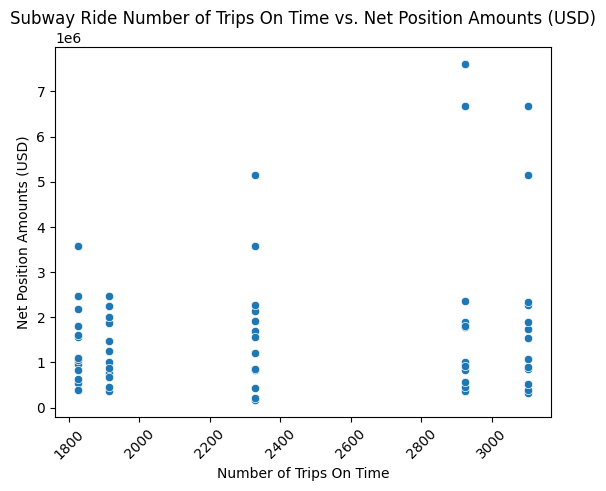

In [72]:
#Feature pairings
#create scatter plots between "ontime_trip_count" and Net Position Amounts (USD)
sns.scatterplot(data = netposition_subset, x= "ontime_trip_count", y = "Net Position Amounts (USD)")
plt.title("Subway Ride Number of Trips On Time vs. Net Position Amounts (USD)")
plt.xticks(rotation=45)
plt.xlabel("Number of Trips On Time")
plt.ylabel("Net Position Amounts (USD)")
plt.show()

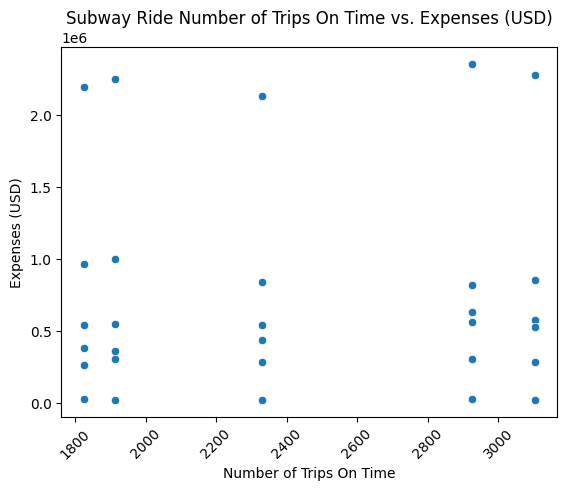

In [74]:
#Feature pairings
#create scatter plots between "ontime_trip_count" and Expenses (USD)
sns.scatterplot(data = exp_subset, x= "ontime_trip_count", y = "Expenses (USD)")
plt.title("Subway Ride Number of Trips On Time vs. Expenses (USD)")
plt.xticks(rotation=45)
plt.xlabel("Number of Trips On Time")
plt.ylabel("Expenses (USD)")
plt.show()

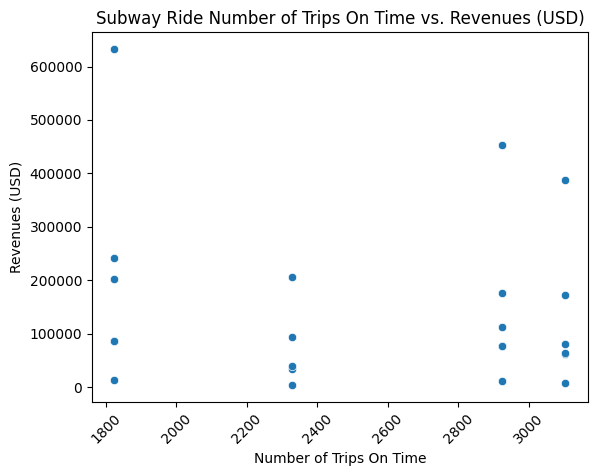

In [76]:
#Feature pairings
#create scatter plots between "ontime_trip_count" and Revenues (USD)
sns.scatterplot(data = rev_subset, x= "ontime_trip_count", y = "Revenue (USD)")
plt.title("Subway Ride Number of Trips On Time vs. Revenues (USD)")
plt.xticks(rotation=45)
plt.xlabel("Number of Trips On Time")
plt.ylabel("Revenues (USD)")
plt.show()

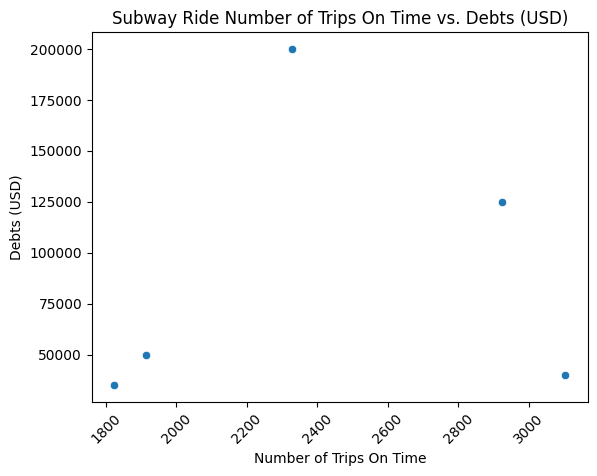

In [81]:
#Feature pairings
#create scatter plots between "ontime_trip_count" and Debts (USD)
sns.scatterplot(data = debts_subset, x= "ontime_trip_count", y = "Debt (USD)")
plt.title("Subway Ride Number of Trips On Time vs. Debts (USD)")
plt.xticks(rotation=45)
plt.xlabel("Number of Trips On Time")
plt.ylabel("Debts (USD)")
plt.show()

## Data Distribution and Normalization:

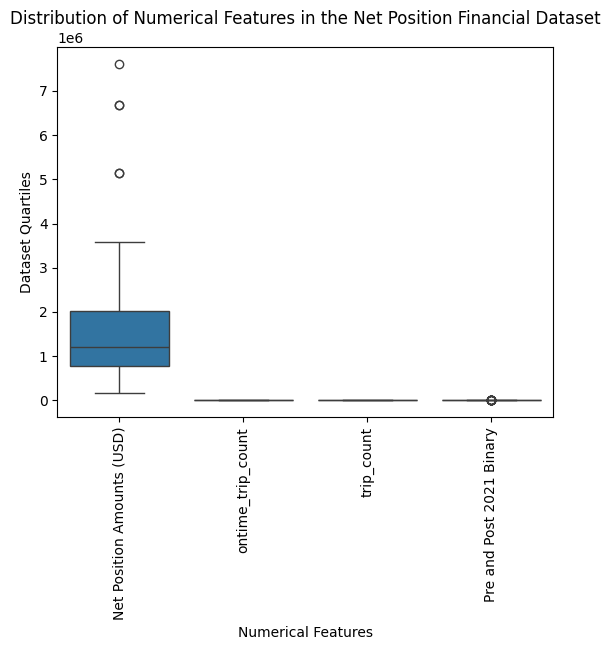

In [82]:
#create new subset of the netposition_df_drop without the 'Pre and Post 2021' column because it was redundant to the 'Pre and Post 2021 Binary'

#create boxplot of dataframe to visualize dataset distribution
sns.boxplot(data= netposition_subset)
plt.title("Distribution of Numerical Features in the Net Position Financial Dataset")
plt.xlabel("Numerical Features")
plt.ylabel("Dataset Quartiles")
plt.xticks(rotation=90)
plt.show()

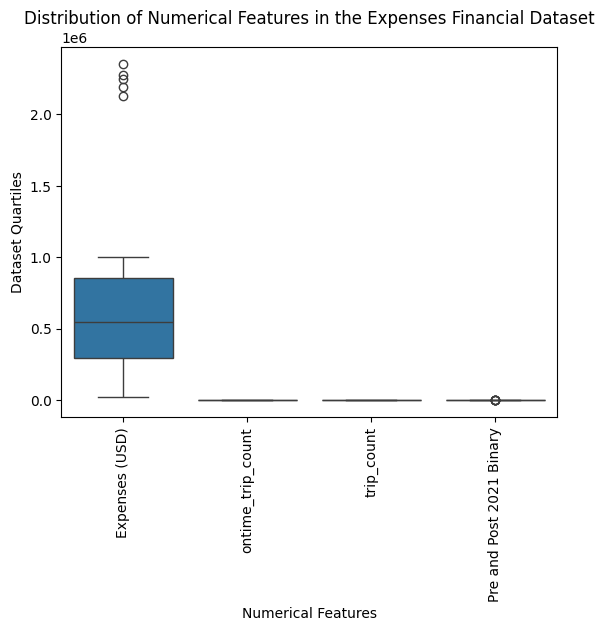

In [84]:
#create new subset of the expenses_df_drop without the 'Pre and Post 2021' column because it was redundant to the 'Pre and Post 2021 Binary'

#create boxplot of dataframe to visualize dataset distribution
sns.boxplot(data= exp_subset)
plt.title("Distribution of Numerical Features in the Expenses Financial Dataset")
plt.xlabel("Numerical Features")
plt.ylabel("Dataset Quartiles")
plt.xticks(rotation=90)
plt.show()

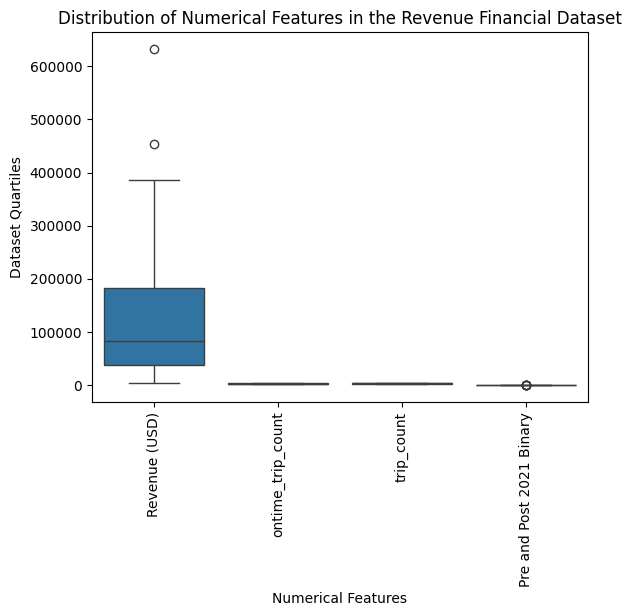

In [85]:
#create new subset of the expenses_df_drop without the 'Pre and Post 2021' column because it was redundant to the 'Pre and Post 2021 Binary'

#create boxplot of dataframe to visualize dataset distribution
sns.boxplot(data= rev_subset)
plt.title("Distribution of Numerical Features in the Revenue Financial Dataset")
plt.xlabel("Numerical Features")
plt.ylabel("Dataset Quartiles")
plt.xticks(rotation=90)
plt.show()

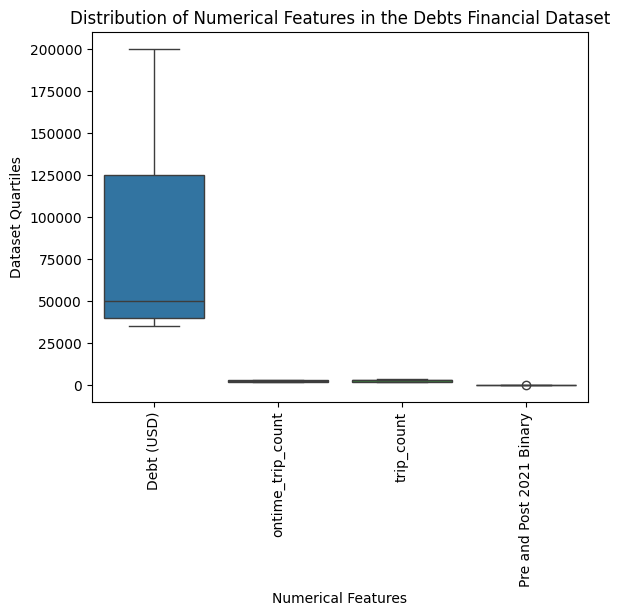

In [86]:
#create new subset of the expenses_df_drop without the 'Pre and Post 2021' column because it was redundant to the 'Pre and Post 2021 Binary'

#create boxplot of dataframe to visualize dataset distribution
sns.boxplot(data= debts_subset)
plt.title("Distribution of Numerical Features in the Debts Financial Dataset")
plt.xlabel("Numerical Features")
plt.ylabel("Dataset Quartiles")
plt.xticks(rotation=90)
plt.show()

In [91]:
#apply z-score normalization on subset of dataframe that only includes numerical values
#create subset of the netposition_subset dataframe to only keep the "ontime_trip_count" and the "Net Position Amounts (USD)" columns
netposition_subset2 = netposition_subset[["ontime_trip_count", "Net Position Amounts (USD)"]]

#convert subset dataframe into an array
netposition_array = np.array(netposition_subset2)

#compute z-score normalization transformation on array of dataframe subset (x-mean)/standard deviation
normalized_netposition = (netposition_array - np.mean(netposition_array) / np.std(netposition_array))
#print(normalized_netposition)

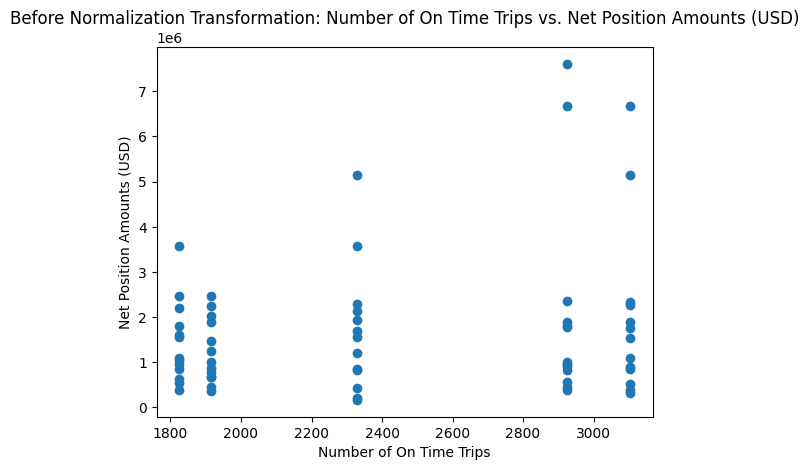

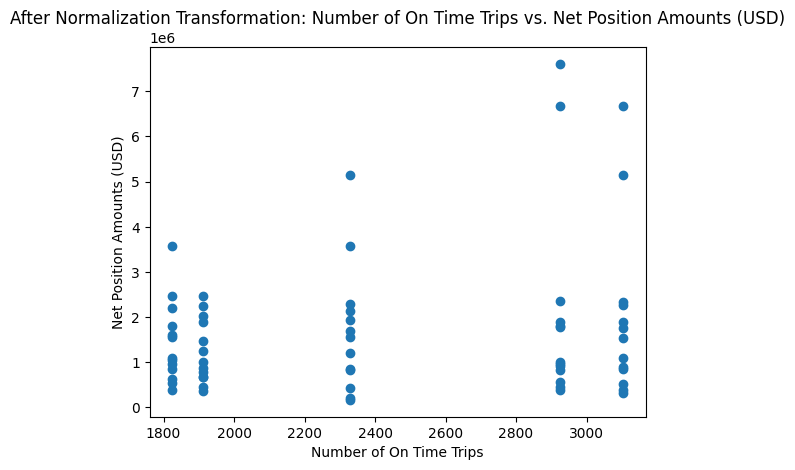

In [92]:
#scatter plot of original data of the "ontime_trip_count" and the "Net Position Amounts (USD)" columns before normalization transformation
plt.scatter(netposition_subset["ontime_trip_count"], netposition_subset["Net Position Amounts (USD)"])
plt.title("Before Normalization Transformation: Number of On Time Trips vs. Net Position Amounts (USD)")
plt.xlabel("Number of On Time Trips")
plt.ylabel("Net Position Amounts (USD)")
plt.show()

#scatter plot of original data of the "num_predictions" and "num_accurate_predictions" columns after normalization transformation
#scatter plot shows normalization of dataset is not necessary
plt.scatter(normalized_netposition[:,0], normalized_netposition[:,1])
plt.title("After Normalization Transformation: Number of On Time Trips vs. Net Position Amounts (USD)")
plt.xlabel("Number of On Time Trips")
plt.ylabel("Net Position Amounts (USD)")
plt.show()

## Statistical Insights:



In [95]:
#create new subset of the net position subset data
#drop the "Pre and Post 2021 Binary" column so when fitting to the logistic regression model, it does not cause a perfect prediction
netposition_subset2 = netposition_subset.drop("Pre and Post 2021 Binary", axis=1)

In [96]:
#Logistic regression model
#determine relationship between the number of predictions and accurate predictions with binary values of the dates
#import the statsmodel libary
import statsmodels.api as sm
#fit logistic regression model onto the Pre and Post 2021 Binary and  column of dataset
log_netposition_model = sm.Logit(netposition_subset["Pre and Post 2021 Binary"], sm.add_constant(netposition_subset2)).fit()
#print logistic model summary
print(log_netposition_model.summary())

#Due to perfect prediction warning message, we decided to not create further logistic regression models

         Current function value: 0.000000
         Iterations: 35
                              Logit Regression Results                              
Dep. Variable:     Pre and Post 2021 Binary   No. Observations:                   65
Model:                                Logit   Df Residuals:                       61
Method:                                 MLE   Df Model:                            3
Date:                      Fri, 13 Dec 2024   Pseudo R-squ.:                   1.000
Time:                              20:39:17   Log-Likelihood:            -1.9287e-08
converged:                            False   LL-Null:                       -32.526
Covariance Type:                  nonrobust   LLR p-value:                 4.888e-14
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       -621.1993   2.09e+05     -0.003     

/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction de

In [108]:
#create new subset of the expenses subset data
#drop the "Pre and Post 2021 Binary" column so when fitting to the logistic regression model, it does not cause a perfect prediction
expenses_subset2 = exp_subset.drop("Pre and Post 2021 Binary", axis=1)

#Logistic regression model
#determine relationship between the number of predictions and accurate predictions with binary values of the dates

#fit logistic regression model onto the Pre and Post 2021 Binary and  column of dataset
#log_expenses_model = sm.Logit(exp_subset["Pre and Post 2021 Binary"], sm.add_constant(expenses_subset2)).fit()
#print logistic model summary
#print(log_expenses_model.summary())

#Decided to not create a logistic regression model of the expenses financial dataset with "Pre and Post 2021 Binary" as predictor due to perfect preditiction warning

In [107]:
#create new subset of the revenue subset data
#drop the "Pre and Post 2021 Binary" column so when fitting to the logistic regression model, it does not cause a perfect prediction
revenue_subset2 = rev_subset.drop("Pre and Post 2021 Binary", axis=1)

#Logistic regression model
#determine relationship between the number of predictions and accurate predictions with binary values of the dates
#fit logistic regression model onto the Pre and Post 2021 Binary and  column of dataset
#log_revenue_model = sm.Logit(rev_subset["Pre and Post 2021 Binary"], sm.add_constant(revenue_subset2)).fit()
#print logistic model summary
#print(log_revenue_model.summary())

#Decided to not create a logistic regression model of the revenue financial dataset with "Pre and Post 2021 Binary" as predictor due to perfect preditiction warning

In [106]:
#create new subset of the debt subset data
#drop the "Pre and Post 2021 Binary" column so when fitting to the logistic regression model, it does not cause a perfect prediction
debt_subset2 = debts_subset.drop("Pre and Post 2021 Binary", axis=1)

#Logistic regression model
#determine relationship between the number of predictions and accurate predictions with binary values of the dates
#fit logistic regression model onto the Pre and Post 2021 Binary and  column of dataset
#log_debt_model = sm.Logit(debts_subset["Pre and Post 2021 Binary"], sm.add_constant(debt_subset2)).fit()
#print logistic model summary
#print(log_debt_model.summary())

#Decided to not create a logistic regression model of the Debts financial dataset with "Pre and Post 2021 Binary" as predictor due to perfect preditiction warning

In [102]:
#two-sample t-test
#import the scipy.stats library
import scipy.stats as stats

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "Net Position Amounts (USD)" features
t_stat, p_value = stats.ttest_ind(netposition_subset["Pre and Post 2021 Binary"], netposition_subset["Net Position Amounts (USD)"])
print("T-statistic: ", t_stat) #print t-statistic
print("p-value: ", p_value) #print p-value


T-statistic:  -8.770311565076161
p-value:  9.443422513225784e-15


In [103]:
#two-sample t-test

#perform two-sample t-test on the "ontime_trip_count" and "Net Position Amounts (USD)" features
t_stat2, p_value2 = stats.ttest_ind(netposition_subset["ontime_trip_count"], netposition_subset["Net Position Amounts (USD)"])
print("T-statistic: ", t_stat2) #print t-statistic
print("p-value: ", p_value2) #print p-value

T-statistic:  -8.75776369811067
p-value:  1.0123982472342289e-14


In [104]:
#two-sample t-test
#perform two-sample t-test on the "ontime_trip_count" and "Expenses (USD)" features
t_stat3, p_value3 = stats.ttest_ind(exp_subset["ontime_trip_count"], exp_subset["Expenses (USD)"])
print("T-statistic: ", t_stat3) #print t-statistic
print("p-value: ", p_value3) #print p-value

T-statistic:  -5.562800200509888
p-value:  7.077394346859824e-07


In [109]:
#two-sample t-test
#perform two-sample t-test on the "ontime_trip_count" and "Revenues (USD)" features
t_stat4, p_value4 = stats.ttest_ind(rev_subset["ontime_trip_count"], rev_subset["Revenue (USD)"])
print("T-statistic: ", t_stat4) #print t-statistic
print("p-value: ", p_value4) #print p-value

T-statistic:  -4.328240746564412
p-value:  8.03339895840829e-05


In [111]:
#two-sample t-test
#perform two-sample t-test on the "ontime_trip_count" and "Debts (USD)" features
t_stat5, p_value5 = stats.ttest_ind(debts_subset["ontime_trip_count"], debts_subset["Debt (USD)"])
print("T-statistic: ", t_stat5) #print t-statistic
print("p-value: ", p_value5) #print p-value

T-statistic:  -2.7388107043103282
p-value:  0.025496067137814025


In [124]:
#Create an ANOVA Analysis of Variance model
#compare means of three or more groups in the net position dataset

import scipy.stats as stats #import library

netposition = netposition_df_drop["Net Position Amounts (USD)"]
ontime = netposition_df_drop["ontime_trip_count"]
trip = netposition_df_drop["trip_count"]
binary_date = netposition_df_drop["Pre and Post 2021 Binary"]

f_stat, p_value = stats.f_oneway(netposition , ontime, trip, binary_date)

print(f_stat, p_value)

76.76442677882271 1.8994029522412697e-35


In [125]:
#Create an ANOVA Analysis of Variance model
#compare means of three or more groups in the revenue dataset

revenue = revenue_df_drop["Revenue (USD)"]
rev_ontime = revenue_df_drop["ontime_trip_count"]
rev_trip = revenue_df_drop["trip_count"]
rev_binary_date = revenue_df_drop["Pre and Post 2021 Binary"]

f_stat_rev, p_value_rev = stats.f_oneway(revenue , rev_ontime, rev_trip, rev_binary_date)

print(f_stat_rev, p_value_rev)

18.945957639590752 1.1885808140875508e-09


In [126]:
#Create an ANOVA Analysis of Variance model
#compare means of three or more groups in the expenses dataset

expenses = expenses_df_drop["Expenses (USD)"]
exp_ontime = expenses_df_drop["ontime_trip_count"]
exp_trip = expenses_df_drop["trip_count"]
exp_binary_date = expenses_df_drop["Pre and Post 2021 Binary"]

f_stat_exp, p_value_exp = stats.f_oneway(expenses, exp_ontime, exp_trip, exp_binary_date)

print(f_stat_exp, p_value_exp)

31.005344983232142 8.586503361300924e-15


In [127]:
#Create an ANOVA Analysis of Variance model
#compare means of three or more groups in the debts dataset

debts = debts_df_drop["Debt (USD)"]
debt_ontime = debts_df_drop["ontime_trip_count"]
debt_trip = debts_df_drop["trip_count"]
debt_binary_date = debts_df_drop["Pre and Post 2021 Binary"]

f_stat_debt, p_value_debt = stats.f_oneway(debts, debt_ontime, debt_trip, debt_binary_date)

print(f_stat_debt, p_value_debt)

7.6306656525419 0.002180526274083107


## Data Visualization and Storytelling:

In [134]:
print(netposition_df_drop.columns)
print(revenue_df_drop.columns)

Index(['Statements of Revenue, Expenses and Changes in Net Position', 'Date',
       'Net Position Amounts (USD)', 'ontime_trip_count', 'trip_count', 'Time',
       'Pre and Post 2021', 'Pre and Post 2021 Binary'],
      dtype='object')
Index(['Sources of Operating Revenue', 'Date', 'Revenue (USD)',
       'ontime_trip_count', 'trip_count', 'Time', 'Pre and Post 2021',
       'Pre and Post 2021 Binary'],
      dtype='object')


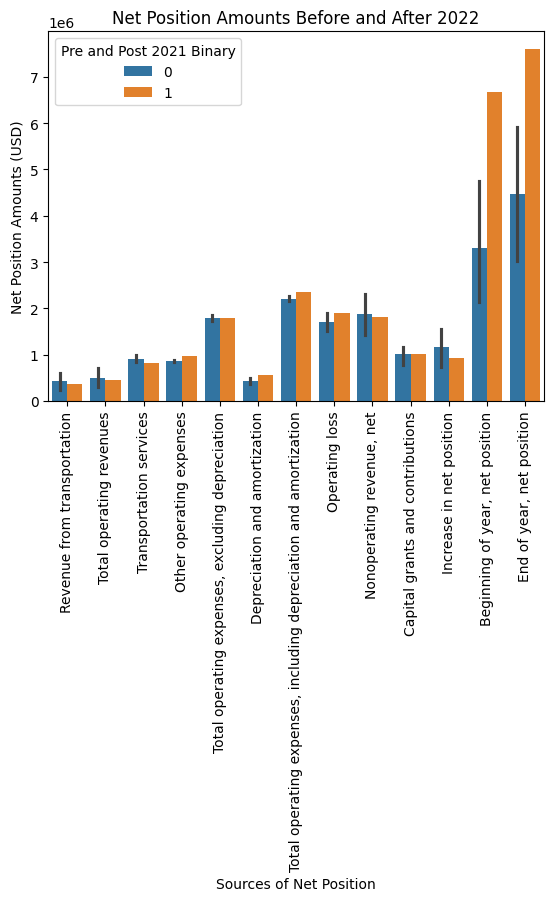

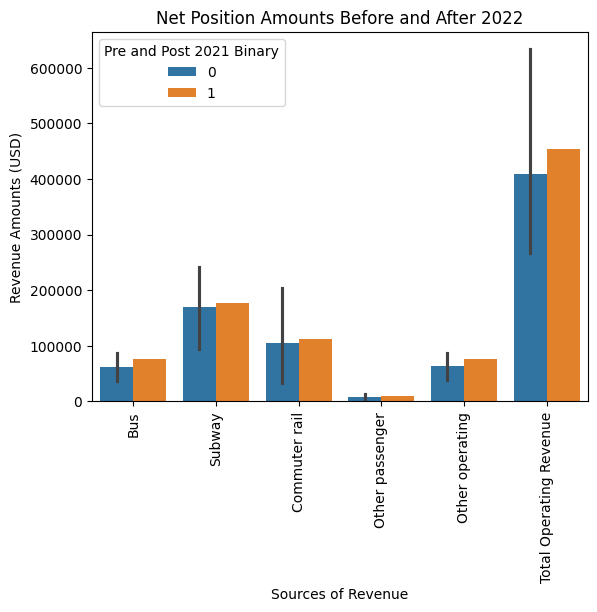

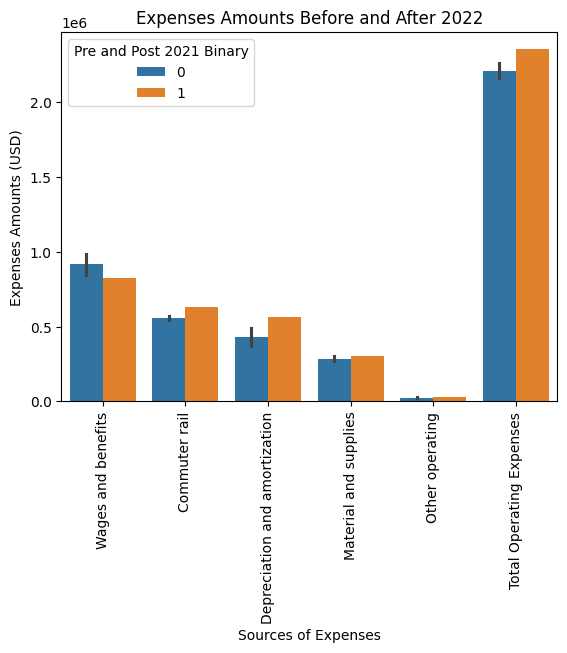

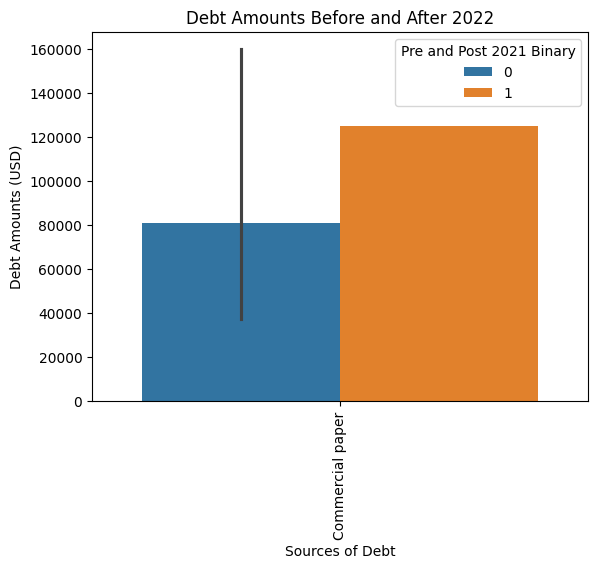

In [139]:
#Create bar graphs of net position dataset
sns.barplot(data = netposition_df_drop, y = 'Net Position Amounts (USD)', x = 'Statements of Revenue, Expenses and Changes in Net Position', hue = 'Pre and Post 2021 Binary')
plt.title("Net Position Amounts Before and After 2022")
plt.xticks(rotation=90)
plt.xlabel("Sources of Net Position")
plt.ylabel("Net Position Amounts (USD)")
plt.show()

#Create bar graphs of revenue dataset
sns.barplot(data = revenue_df_drop, y = 'Revenue (USD)', x = 'Sources of Operating Revenue', hue = 'Pre and Post 2021 Binary')
plt.title("Net Position Amounts Before and After 2022")
plt.xticks(rotation=90)
plt.xlabel("Sources of Revenue")
plt.ylabel("Revenue Amounts (USD)")
plt.show()

#Create bar graphs of expenses dataset
sns.barplot(data = expenses_df_drop, y = 'Expenses (USD)', x = 'Sources of Operating Expenses', hue = 'Pre and Post 2021 Binary')
plt.title("Expenses Amounts Before and After 2022")
plt.xticks(rotation=90)
plt.xlabel("Sources of Expenses")
plt.ylabel("Expenses Amounts (USD)")
plt.show()


#Create bar graphs of debt dataset
sns.barplot(data = debts_df_drop, y = 'Debt (USD)', x = 'Sources of Debt', hue = 'Pre and Post 2021 Binary')
plt.title("Debt Amounts Before and After 2022")
plt.xticks(rotation=90)
plt.xlabel("Sources of Debt")
plt.ylabel("Debt Amounts (USD)")
plt.show()

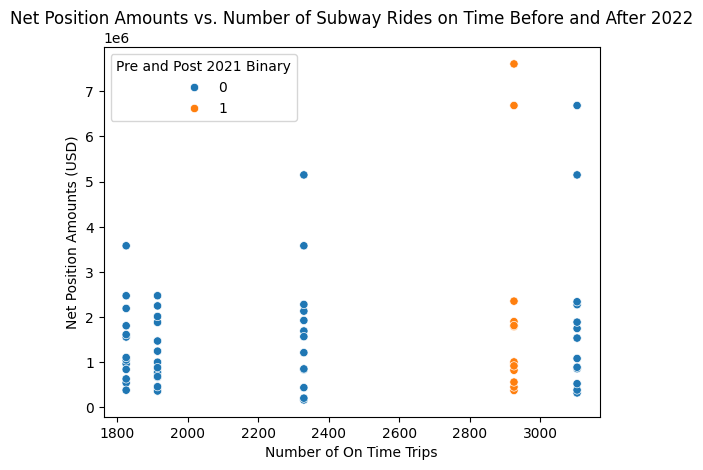

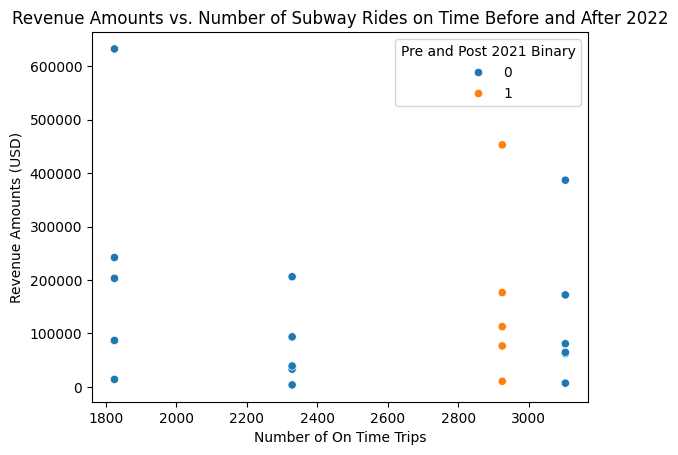

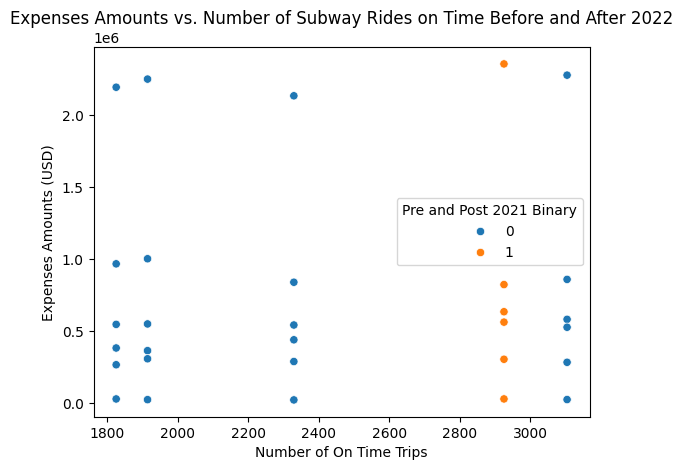

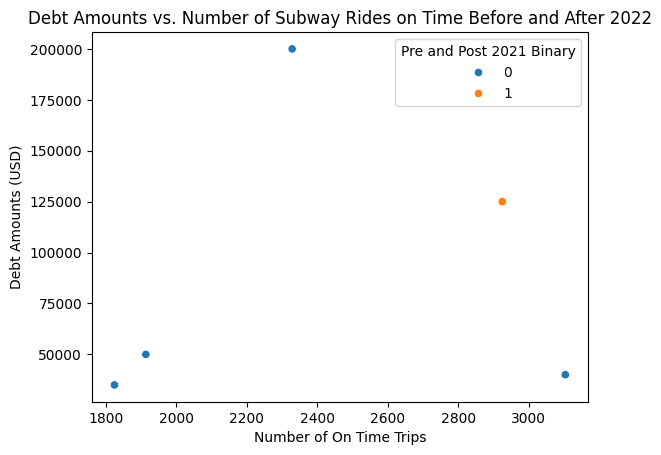

In [145]:
#Create scatter plot of net position dataset
sns.scatterplot(data = netposition_df_drop, y = 'Net Position Amounts (USD)', x = 'ontime_trip_count', hue = 'Pre and Post 2021 Binary')
plt.title("Net Position Amounts vs. Number of Subway Rides on Time Before and After 2022")
plt.xlabel("Number of On Time Trips")
plt.ylabel("Net Position Amounts (USD)")
plt.show()

#Create scatter plot of revenue dataset
sns.scatterplot(data = revenue_df_drop, y = 'Revenue (USD)', x = 'ontime_trip_count', hue = 'Pre and Post 2021 Binary')
plt.title("Revenue Amounts vs. Number of Subway Rides on Time Before and After 2022")
plt.xlabel("Number of On Time Trips")
plt.ylabel("Revenue Amounts (USD)")
plt.show()

#Create scatter plot of expenses dataset
sns.scatterplot(data = expenses_df_drop, y = 'Expenses (USD)', x = 'ontime_trip_count', hue = 'Pre and Post 2021 Binary')
plt.title("Expenses Amounts vs. Number of Subway Rides on Time Before and After 2022")
plt.xlabel("Number of On Time Trips")
plt.ylabel("Expenses Amounts (USD)")
plt.show()

#Create scatter plot of debts dataset
sns.scatterplot(data = debts_df_drop, y = 'Debt (USD)', x = 'ontime_trip_count', hue = 'Pre and Post 2021 Binary')
plt.title("Debt Amounts vs. Number of Subway Rides on Time Before and After 2022")
plt.xlabel("Number of On Time Trips")
plt.ylabel("Debt Amounts (USD)")
plt.show()

## Conclusions and Next Steps: